In [ ]:
!pip install --upgrade ultralytics



In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="ta18Dp4JpDievmIAMw6P")
project = rf.workspace("titulacin").project("person-detection-9a6mk")
version = project.version(6)
dataset = version.download("yolov8")




loading Roboflow workspace...
loading Roboflow project...


In [ ]:
from ultralytics import YOLO

# Load a pretrained YOLO model
# The model file is downloaded as part of the dataset from Roboflow
model = YOLO(f"{dataset.location}/yolov8s.pt")  # You can choose a different YOLO model like yolov8s.pt, yolov8m.pt, etc.

# Train the model with resumable training enabled
# The 'resume=True' argument will automatically resume from the last saved checkpoint
# if training is interrupted.
results = model.train(data=f"{dataset.location}/data.yaml", epochs=25, imgsz=500)

print("Training finished.")

Ultralytics 8.3.208 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Person-detection-6/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=500, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/Person-detection-6/yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train5, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10

In [ ]:
# Run the training cell to define and load the model
get_ipython().run_cell('1UqUnJ51sWE-')

In [ ]:
from google.colab import files
uploaded = files.upload()



Saving sample image 3.jpg to sample image 3 (1).jpg



image 1/1 /content/sample image 3.jpg: 288x512 18 Personas, 8.8ms
Speed: 1.6ms preprocess, 8.8ms inference, 1.3ms postprocess per image at shape (1, 3, 288, 512)


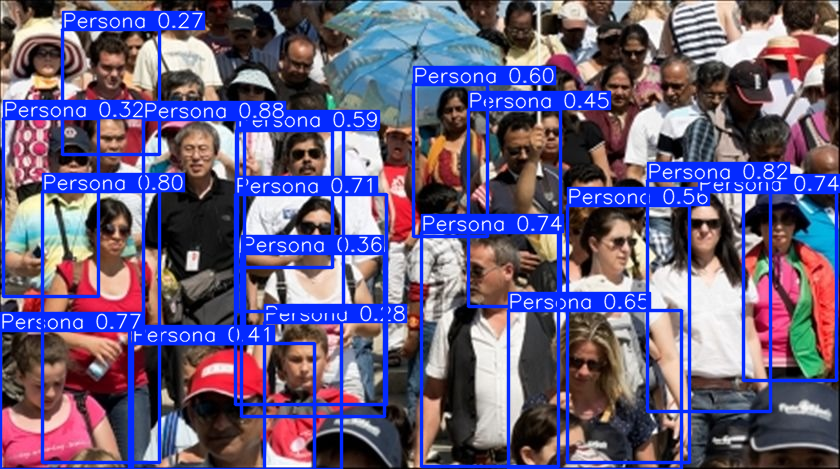

Number of people detected: 18


In [ ]:
results = model.predict(source="sample image 3.jpg", conf=0.25)
results[0].show()
num_people = len(results[0].boxes)
print(f"Number of people detected: {num_people}")
